# Surface flux anomalies and piControl climatologies (Figures S1–S2)

We map decadal-mean Historical/SSP5-8.5 anomalies of sea ice, surface fluxes, wind stress, and surface temperature and salinity relative to the piControl climatology (`figS01_surface_flux_anomalies.png`), and the piControl climatology itself (`figS02_surface_flux_baselines.png`). The surface fields come from `04_prepare_surface_properties`, and the shelf outline is the ACS region used in `01_prepare_dsw_wmt_budget`.

In [1]:
import string
import sys

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cmocean.cm as cmo

sys.path.insert(0, "../src")
from paths import outputdir, plotsdir
from cm4x import cm4x_acs_mask
from plotting import set_style, make_center_extended_cmap, plot_antarctic

set_style(dpi=150)



In [2]:
from dask.distributed import Client
from dask_jobqueue import SLURMCluster

# 8 nodes (36 cores, 160 GB each) to read the 50 files and sum the fluxes over sigma2 in parallel
cluster = SLURMCluster(cores=36, processes=1, memory="160GB", walltime="01:00:00",
                       queue="scavenger", log_directory="logs")
cluster.scale(jobs=8)
cluster.wait_for_workers(2)
client = Client(cluster)
client

<Client: 'tcp://10.151.1.98:39137' processes=3 threads=108, memory=447.03 GiB>

## Load data

In [3]:
seconds_per_year = 3.154e7
rho_fw = 1000.0  # freshwater density [kg/m^3], converts kg/m^2/s to m/yr

ds_sfc = xr.open_mfdataset(
    outputdir("Southern_Ocean_50S_Monthly_Surface_Fluxes_And_Properties.zarr"), engine="zarr"
)
if "sigma2_l" in ds_sfc.dims:  # fluxes are split across the sigma2 classes occupied each month; sum them before any averaging
    ds_sfc = ds_sfc.assign({v: ds_sfc[v].sum("sigma2_l", min_count=1) for v in ["fsitherm", "hfsso"]}).drop_dims("sigma2_l")
ds_sfc["sivol"] = ds_sfc["sithick"] * ds_sfc["siconc"] * ds_sfc["areacello"]  # sea ice volume per cell [m^3]
sfc = ds_sfc[["siconc", "sithick", "sivol", "fsitherm", "hfsso", "taux", "tos", "sos", "areacello", "wet"]]
sfc = sfc.groupby("time.year").mean("time").compute()
sfc = sfc.where(sfc["wet"] > 0.0)

acs_mask = cm4x_acs_mask()

Inferring Z grid coordinate: density `sigma2`


## piControl climatology and Historical/SSP5-8.5 anomalies

In [9]:
baseline = sfc.sel(exp="control").mean("year")
anomaly = sfc.sel(exp="forced") - baseline

zero_color = cmo.balance(0.5)


def draw_acs_outline(ax, acs_mask):
    ax.contour(
        acs_mask.geolon, acs_mask.geolat, 1.0 * acs_mask,
        levels=[0.5], transform=ccrs.PlateCarree(), colors="white", zorder=100,
    )


def add_map_label(ax, label):
    ax.text(
        0.48, 0.53, label, transform=ax.transAxes, ha="left", va="top",
        fontsize=16, fontweight="bold", zorder=300,
    )
sea_ice_anom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "sea_ice_anom",
    ["#551a55", "#cc4c5a", "#f3c884", "#f0f0f0", "#c7e5e3", "#4785b7", "#29284f"],
)

## Figure S1

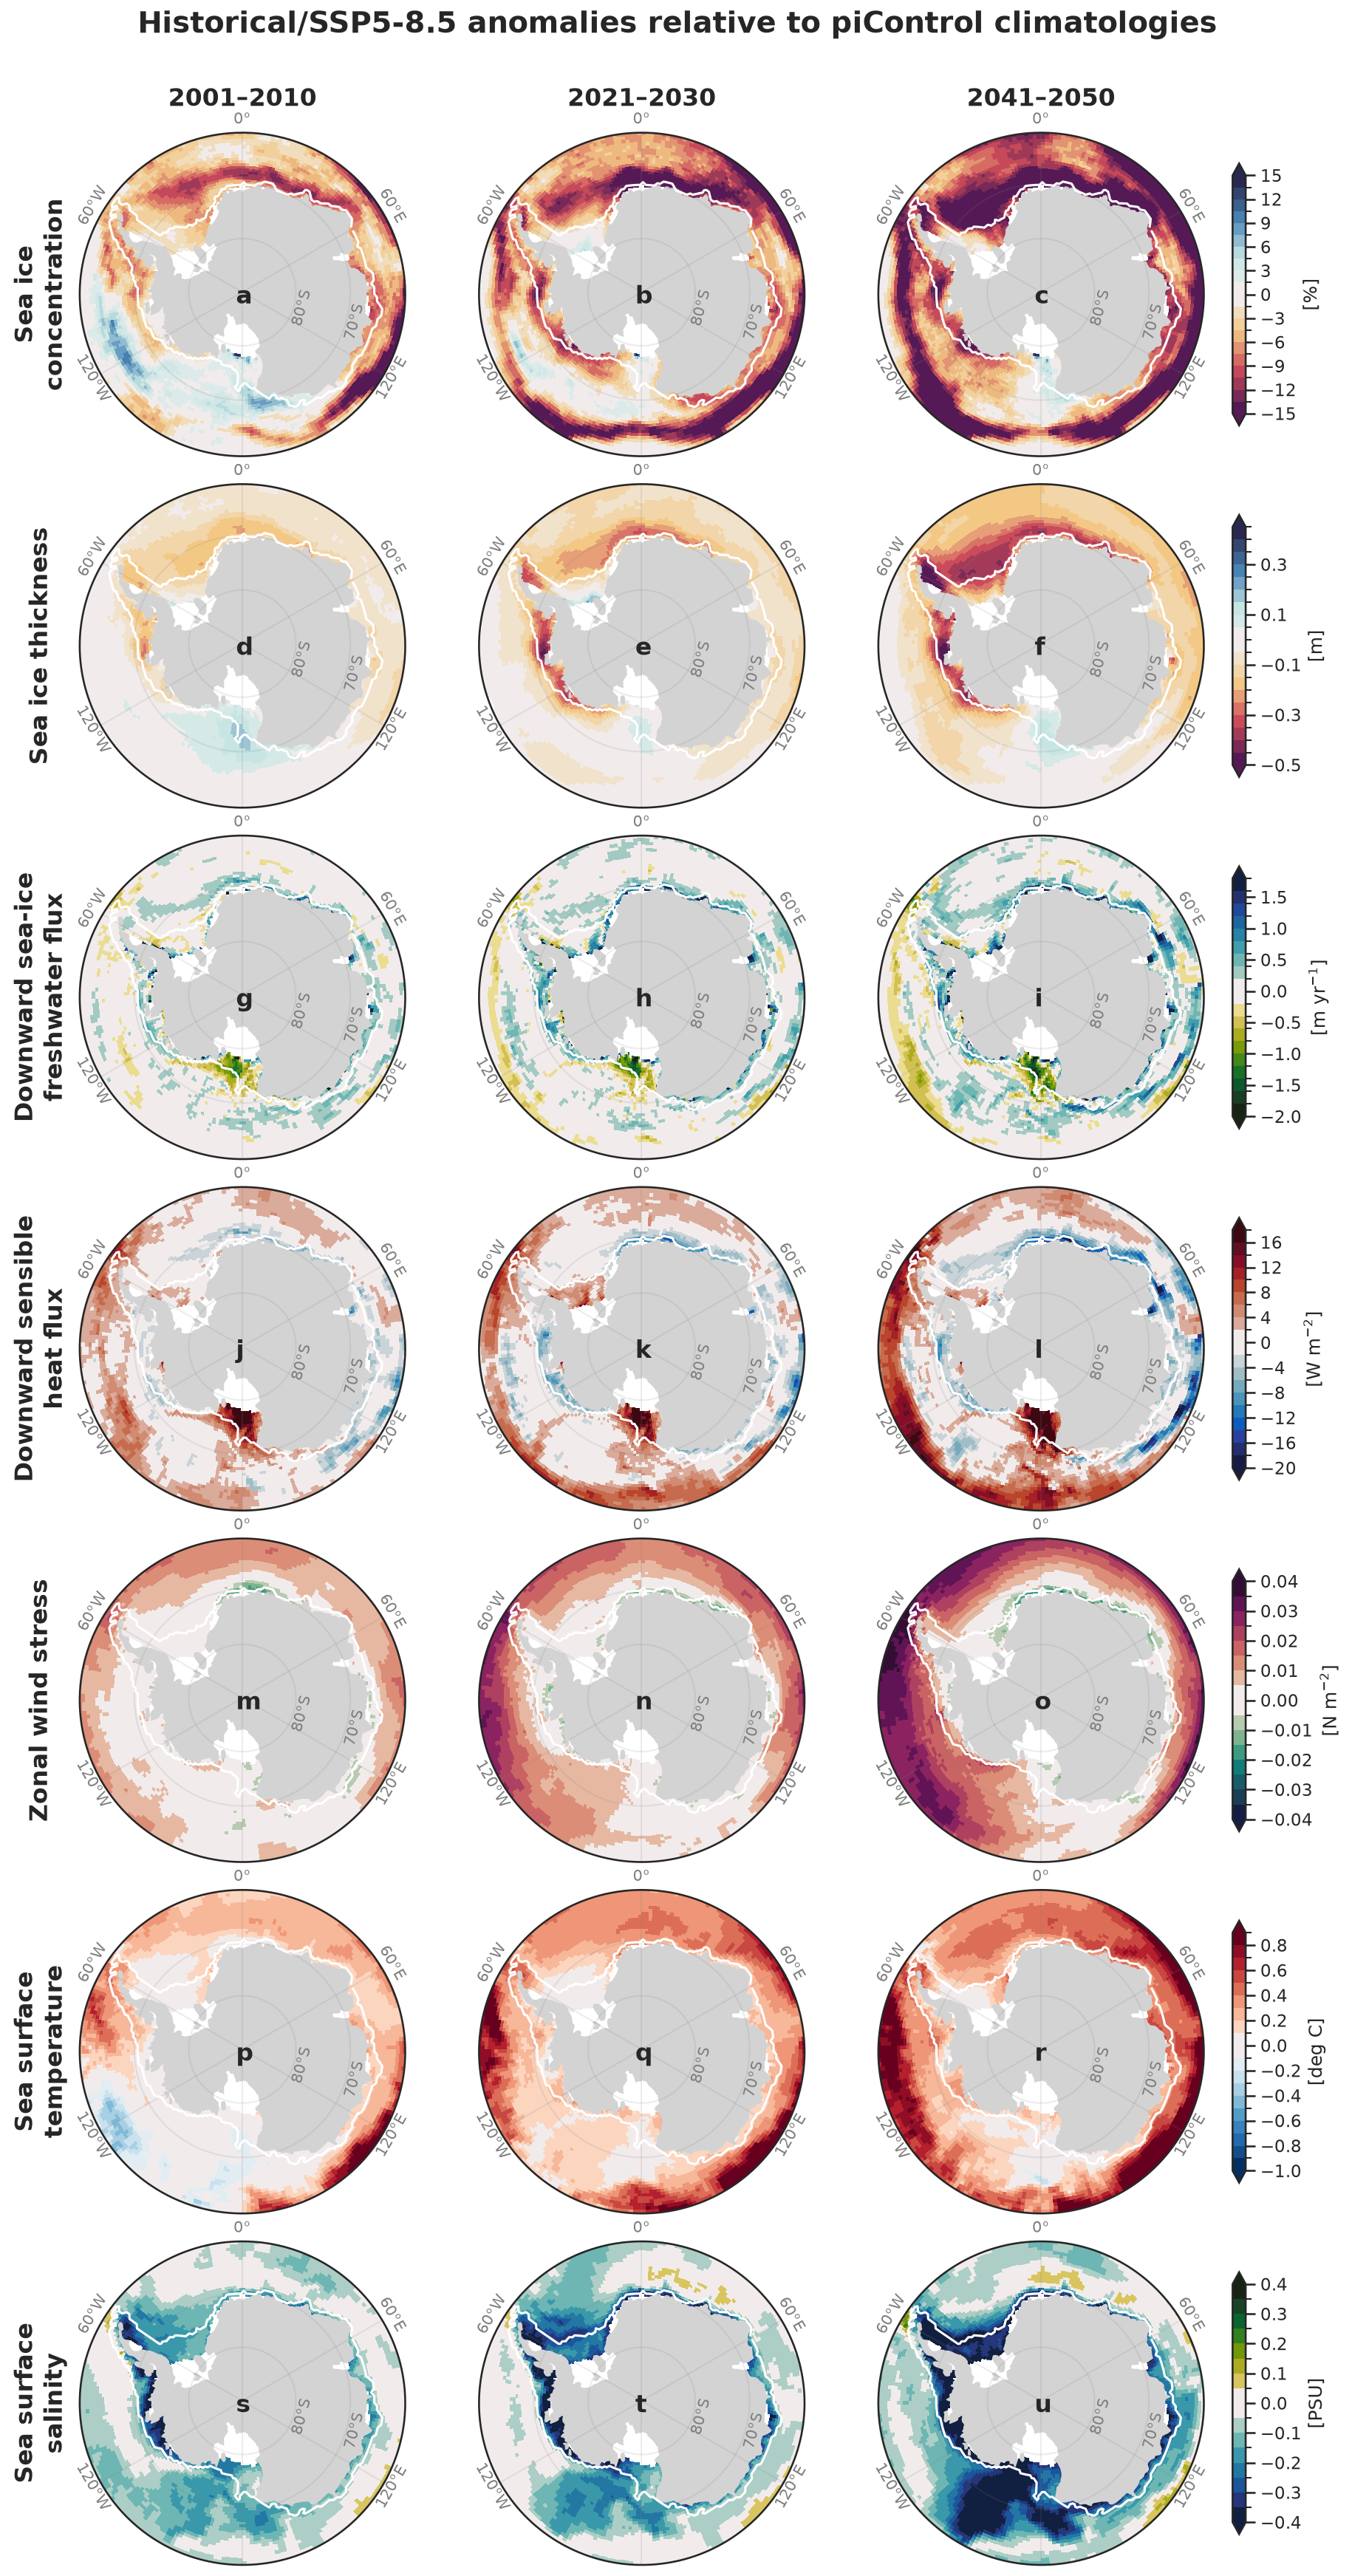

In [12]:
year_ranges = [(2001, 2010), (2021, 2030), (2041, 2050)]

anomaly_specs = [
    {
        "name": "Sea ice\nconcentration",
        "data": 100 * anomaly["siconc"],
        "label": "[%]",
        "levels": np.arange(-15, 15.01, 1.5),
        "ticks": np.arange(-15, 16, 3),
        "cmap": sea_ice_anom_cmap,
    },
    {
        "name": "Sea ice thickness",
        "data": anomaly["sivol"] / anomaly["areacello"],
        "label": "[m]",
        "levels": np.arange(-.50, .5 + 1e-16, 0.05),
        "ticks": np.arange(-.50, 0.51, 0.2),
        "cmap": sea_ice_anom_cmap,
    },
    {
        "name": "Downward sea-ice\nfreshwater flux",
        "data": anomaly["fsitherm"] * seconds_per_year / rho_fw,
        "label": r"[m yr$^{-1}$]",
        "levels": np.arange(-2, 2 + 1e-16, 0.2),
        "ticks": np.arange(-2, 2 + 1e-16, 0.5),
        "cmap": cmo.delta_r,
    },
    {
        "name": "Downward sensible\nheat flux",
        "data": anomaly["hfsso"],
        "label": r"[W m$^{-2}$]",
        "levels": np.arange(-20, 20 + 1e-16, 2),
        "ticks": np.arange(-20, 20 + 1e-16, 4),
        "cmap": cmo.balance,
    },
    {
        "name": "Zonal wind stress",
        "data": anomaly["taux"],
        "label": r"[N m$^{-2}$]",
        "levels": np.arange(-0.04, 0.04 + 1e-16, 0.005),
        "ticks": np.arange(-0.04, 0.04 + 1e-16, 0.01),
        "cmap": cmo.curl,
    },
    {
        "name": "Sea surface\ntemperature",
        "data": anomaly["tos"],
        "label": "[deg C]",
        "levels": np.arange(-1, 1 + 1e-16, 0.1),
        "ticks": np.arange(-1, 1 + 1e-16, 0.2),
        "cmap": "RdBu_r",
    },
    {
        "name": "Sea surface\nsalinity",
        "data": anomaly["sos"],
        "label": "[PSU]",
        "levels": np.arange(-0.4, 0.4 + 1e-16, 0.05),
        "ticks": np.arange(-0.4, 0.4 + 1e-16, 0.1),
        "cmap": cmo.delta,
    },
]

nrows, ncols = len(anomaly_specs), len(year_ranges)
fig, ax = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 3.2 * nrows),
                       subplot_kw={"projection": ccrs.SouthPolarStereo()},
                       constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.005, h_pad=0.02, wspace=0.005, hspace=0.02)
labels = iter(string.ascii_lowercase)

for row, spec in enumerate(anomaly_specs):
    cmap, norm = make_center_extended_cmap(spec["levels"], cmap_name=spec["cmap"], zero_color=zero_color)
    for col, (start_year, end_year) in enumerate(year_ranges):
        this_ax = ax[row, col]
        this_ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
        decade_mean = spec["data"].sel(year=slice(start_year, end_year)).mean("year")
        cm = plot_antarctic(decade_mean, this_ax, cmap=cmap, norm=norm, mask_threshold=-np.inf, draw_labels=True)

        if row == 0:
            this_ax.set_title(f"{start_year}–{end_year}", pad=9, fontweight="bold", fontsize=16, y=1.04)
        if col == 0:
            this_ax.text(-0.12, 0.5, spec["name"], transform=this_ax.transAxes, rotation=90,
                         va="center", ha="center", fontsize=16, fontweight="bold")
        draw_acs_outline(this_ax, acs_mask)
        add_map_label(this_ax, next(labels))

    fig.colorbar(cm, ax=ax[row, :], orientation="vertical", fraction=0.011, pad=0.02,
                 extend="both", ticks=spec["ticks"], label=spec["label"])

fig.suptitle("Historical/SSP5-8.5 anomalies relative to piControl climatologies",
             fontsize=19, fontweight="bold", y=1.03)
fig.savefig(plotsdir("figS01_surface_flux_anomalies.png"), dpi=350, bbox_inches="tight")

## Figure S2

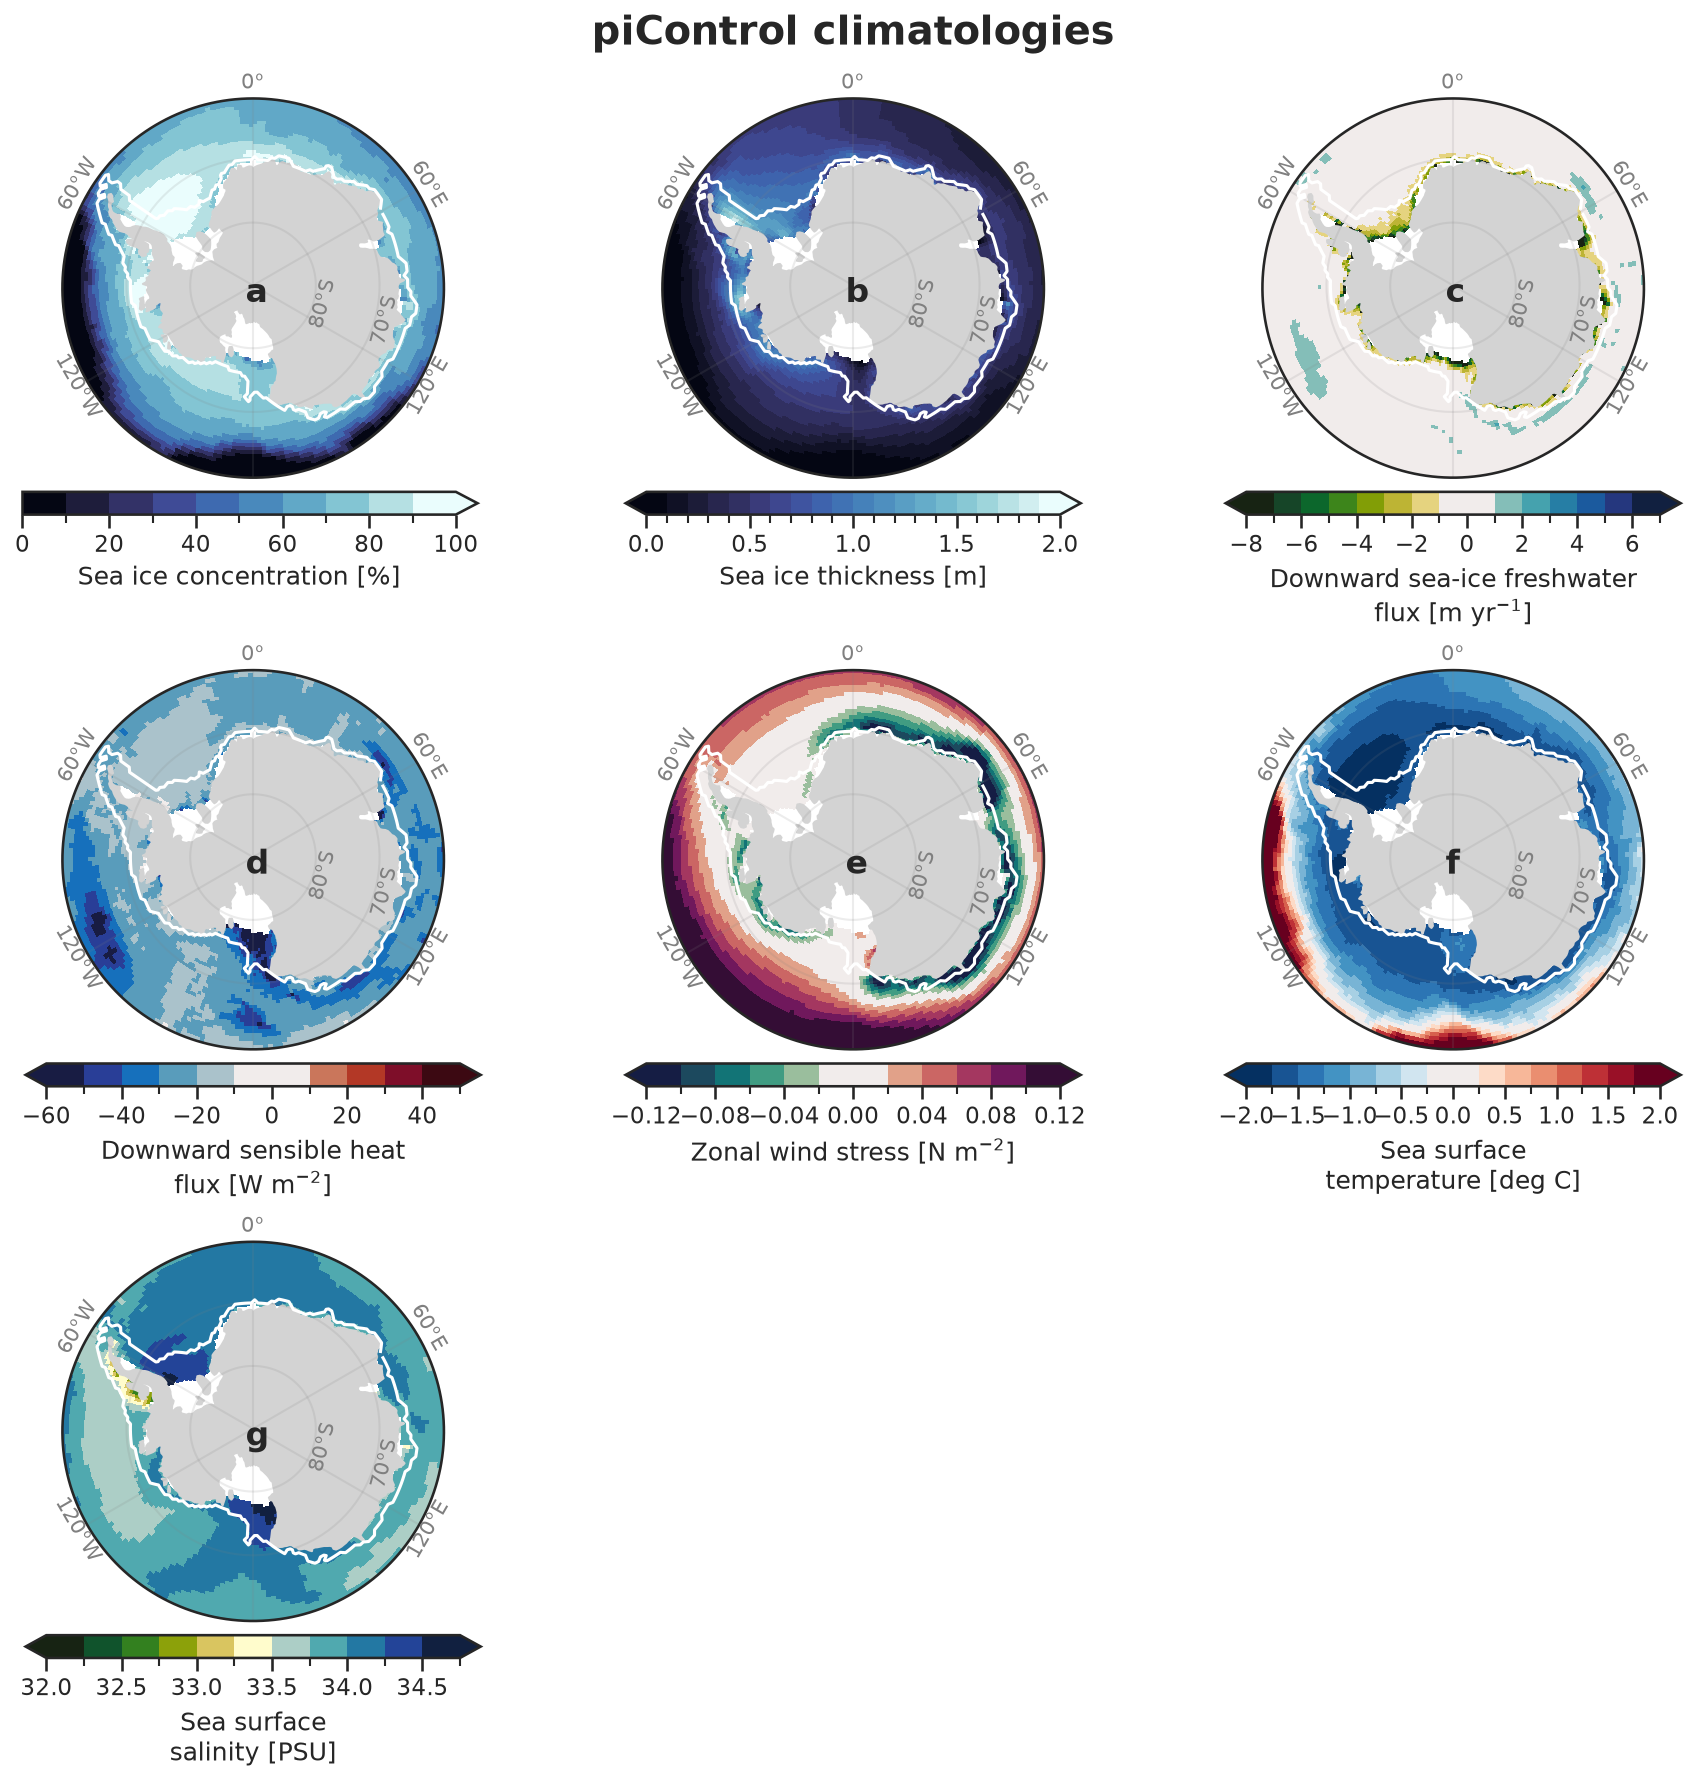

In [13]:
baseline_specs = [
    {
        "data": 100 * baseline["siconc"],
        "label": "Sea ice concentration [%]",
        "levels": np.arange(0, 100.01, 10),
        "ticks": np.arange(0, 101, 20),
        "cmap": cmo.ice,
        "extend": "max",
    },
    {
        "data": baseline["sithick"],
        "label": "Sea ice thickness [m]",
        "levels": np.arange(0, 2.1, 0.1),
        "ticks": np.arange(0, 2.1, 0.5),
        "cmap": cmo.ice,
        "extend": "both",
    },
    {
        "data": baseline["fsitherm"] * seconds_per_year / rho_fw,
        "label": "Downward sea-ice freshwater\nflux " + r"[m yr$^{-1}$]",
        "levels": np.arange(-8, 8 + 1e-16, 1),
        "ticks": np.arange(-8, 8 + 1e-16, 2),
        "cmap": cmo.delta_r,
        "extend": "both",
    },
    {
        "data": baseline["hfsso"],
        "label": "Downward sensible heat\nflux " + r"[W m$^{-2}$]",
        "levels": np.arange(-60, 60 + 1e-16, 10),
        "ticks": np.arange(-60, 60 + 1e-16, 20),
        "cmap": cmo.balance,
        "extend": "both",
    },
    {
        "data": baseline["taux"],
        "label": "Zonal wind stress " + r"[N m$^{-2}$]",
        "levels": np.arange(-0.12, 0.12 + 1e-16, 0.02),
        "ticks": np.arange(-0.12, 0.12 + 1e-16, 0.04),
        "cmap": cmo.curl,
        "extend": "both",
    },
    {
        "data": baseline["tos"],
        "label": "Sea surface\ntemperature [deg C]",
        "levels": np.arange(-2, 2.1, 0.25),
        "ticks": np.arange(-2, 2.1, 0.5),
        "cmap": "RdBu_r",
        "extend": "both",
    },
    {
        "data": baseline["sos"],
        "label": "Sea surface\nsalinity [PSU]",
        "levels": np.arange(32, 35 + 1e-16, 0.25),
        "ticks": np.arange(32, 35 + 1e-16, 0.5),
        "cmap": cmo.delta_r,
        "extend": "both",
    },
]

nplots, ncols = len(baseline_specs), 3
nrows = int(np.ceil(nplots / ncols))
fig, ax = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 3.8 * nrows),
                       subplot_kw={"projection": ccrs.SouthPolarStereo()},
                       constrained_layout=True, squeeze=False)
labels = string.ascii_lowercase

for i, spec in enumerate(baseline_specs):
    this_ax = ax[divmod(i, ncols)]
    levels = spec["levels"]
    this_ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

    if np.any(np.isclose(levels, 0.0)) and levels[0] < 0 < levels[-1]:
        cmap, norm = make_center_extended_cmap(levels, cmap_name=spec["cmap"], zero_color=zero_color)
    else:
        cmap = plt.get_cmap(spec["cmap"])
        norm = mcolors.BoundaryNorm(levels, cmap.N)

    cm = plot_antarctic(spec["data"], this_ax, cmap=cmap, norm=norm, mask_threshold=-np.inf, draw_labels=True)
    draw_acs_outline(this_ax, acs_mask)
    add_map_label(this_ax, labels[i])
    fig.colorbar(cm, ax=this_ax, orientation="horizontal", fraction=0.06, pad=0.035,
                 extend=spec["extend"], ticks=spec["ticks"], label=spec["label"])

for j in range(nplots, nrows * ncols):
    ax[divmod(j, ncols)].set_visible(False)

fig.suptitle("piControl climatologies", fontsize=19, fontweight="bold", y=1.03)
fig.savefig(plotsdir("figS02_surface_flux_baselines.png"), dpi=350, bbox_inches="tight")